# Day 28 - Customer Sales Linear Regression

## 분석 목적

고객의 최근 행동 데이터를 이용하여
향후 30일 매출을 예측하는 선형회귀 모델을 학습한다.

단순히 모델을 실행하는 데서 끝내지 않고
평균 예측 기준선과 성능을 비교한다.

MAE, RMSE, R²를 이용해 테스트 성능을 평가하고
회귀계수와 잔차를 함께 확인한다.

## 분석 질문

1. 고객의 최근 행동으로 다음 30일 매출을 예측할 수 있는가?
2. 선형회귀 모델은 평균 기준선보다 성능이 좋은가?
3. 예측값은 실제값에서 평균적으로 얼마나 차이가 나는가?
4. 큰 예측 오류는 어느 정도 존재하는가?
5. 각 Feature의 회귀계수는 어떤 방향을 나타내는가?
6. 잔차에는 특정한 패턴이 존재하는가?

## 데이터 정의

분석 단위:

고객 1명 = 1행

Feature:

- website_visits_30d
- order_count_90d
- membership_months
- avg_discount_rate_90d

Target:

- next_30d_sales

Feature는 예측 시점 이전의 고객 행동이고,
Target은 이후 30일의 매출이다.

현재 데이터는 머신러닝 학습을 위해 생성한
가상 데이터이므로 실제 고객 행동에 일반화하지 않는다.

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


project_root = Path.cwd().parent

input_path = (
    project_root
    / "data"
    / "raw"
    / "Day28_customer_sales_regression.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(input_path)
print(input_path.exists())

d:\Study\Projects\00_foundation_review\data\raw\day28_customer_sales_regression.csv
False


In [ ]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.shape
)

print(
    df.head()
)

(500, 6)
  customer_id  website_visits_30d  order_count_90d  membership_months  \
0       C0001                  30                4                 50   
1       C0002                  34                3                 10   
2       C0003                  29                3                  7   
3       C0004                  24                3                 34   
4       C0005                  25               11                  8   

   avg_discount_rate_90d  next_30d_sales  
0                  0.037          168362  
1                  0.080          139554  
2                  0.027          120355  
3                  0.090          207844  
4                  0.035          337337  


In [ ]:
# 데이터 구조 확인
print(
    df.dtypes
)

print(
    df.isna().sum()
)

customer_id                  str
website_visits_30d         int64
order_count_90d            int64
membership_months          int64
avg_discount_rate_90d    float64
next_30d_sales             int64
dtype: object
customer_id              0
website_visits_30d       0
order_count_90d          0
membership_months        0
avg_discount_rate_90d    0
next_30d_sales           0
dtype: int64


In [5]:
# 기본 통계
print(
    df[
        [
            "website_visits_30d",
            "order_count_90d",
            "membership_months",
            "avg_discount_rate_90d",
            "next_30d_sales",
        ]
    ].describe()
)

       website_visits_30d  order_count_90d  membership_months  \
count          500.000000       500.000000         500.000000   
mean            28.844000         3.510000          29.018000   
std              6.506946         1.953851          16.912295   
min             13.000000         0.000000           1.000000   
25%             24.000000         2.000000          14.000000   
50%             29.000000         3.000000          29.000000   
75%             33.000000         5.000000          43.000000   
max             46.000000        12.000000          60.000000   

       avg_discount_rate_90d  next_30d_sales  
count             500.000000      500.000000  
mean                0.067548   195607.592000  
std                 0.038785    58429.878232  
min                 0.001000    60719.000000  
25%                 0.037000   154317.750000  
50%                 0.062000   191595.000000  
75%                 0.090000   230920.250000  
max                 0.223000   415786.

## Feature와 Target

customer_id는 고객을 구분하는 식별자일 뿐
숫자의 크기에 분석 의미가 없으므로 Feature에서 제외한다.

예측 시점 이전에 알 수 있는 네 개의 고객 행동 변수를 Feature로 사용하고,
향후 30일 매출을 Target으로 사용한다.

In [6]:
# X와 y
feature_columns = [
    "website_visits_30d",
    "order_count_90d",
    "membership_months",
    "avg_discount_rate_90d",
]

X = df[
    feature_columns
]

y = df[
    "next_30d_sales"
]

print(
    X.shape
)

print(
    y.shape
)

(500, 4)
(500,)


In [7]:
# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (375, 4)
X_test: (125, 4)
y_train: (375,)
y_test: (125,)


## 평균 기준선

선형회귀가 실제로 의미 있는지 판단하려면
단순한 기준선과 비교해야 한다.

이번 회귀 문제에서는 Train 데이터의 평균 매출을
모든 Test 고객에게 동일하게 예측하는 방법을 기준선으로 사용한다.

In [8]:
# Baseline
baseline_mean = (
    y_train
    .mean()
)

baseline_prediction = (
    [baseline_mean]
    * len(y_test)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

print(
    "Train 평균:",
    baseline_mean
)

print(
    "Baseline MAE:",
    baseline_mae
)

Train 평균: 194286.79733333332
Baseline MAE: 43902.539136


## 선형회귀 모델

LinearRegression()으로 모델을 준비하고,
fit()으로 Train 데이터를 이용해 계수를 학습한다.

Test 데이터는 모델 학습에 사용하지 않는다.

In [10]:
# 모델 학습
model = LinearRegression()

model.fit(
    X_train,
    y_train
);

In [11]:
# Test 예측
prediction = model.predict(
    X_test
)

print(
    prediction[:5]
)

[261206.7397821  204186.83482823 166630.41751141 175143.86297525
 189863.1208976 ]


## 회귀 평가 지표

이번 모델은 다음 세 가지 지표로 평가한다.

MAE:
평균적인 절대 오차

RMSE:
큰 오차에 더 큰 벌점을 주는 오차

R²:
평균 예측과 비교해 모델이 Target의 변동을
얼마나 더 설명하는지 나타내는 지표

In [12]:
# MAE / RMSE / R2
model_mae = mean_absolute_error(
    y_test,
    prediction
)

model_rmse = (
    mean_squared_error(
        y_test,
        prediction
    )
    ** 0.5
)

model_r2 = r2_score(
    y_test,
    prediction
)

print(
    "Baseline MAE:",
    baseline_mae
)

print(
    "Model MAE:",
    model_mae
)

print(
    "Model RMSE:",
    model_rmse
)

print(
    "Model R²:",
    model_r2
)

Baseline MAE: 43902.539136
Model MAE: 29895.554334637553
Model RMSE: 38314.37890047951
Model R²: 0.5438576027580646


## 모델 평가

먼저 Model MAE와 Baseline MAE를 비교한다.

Model MAE가 Baseline MAE보다 충분히 작다면,
최근 고객 행동 Feature를 사용하는 선형회귀가
단순 평균 예측보다 유용한 정보를 사용하고 있다고 볼 수 있다.

다만 모델의 실제 사용 가능성은
오차 크기가 업무에서 허용 가능한 수준인지까지 판단해야 한다.

In [13]:
# 평가표
metrics_df = pd.DataFrame(
    {
        "metric": [
            "baseline_mae",
            "model_mae",
            "model_rmse",
            "model_r2",
        ],
        "value": [
            baseline_mae,
            model_mae,
            model_rmse,
            model_r2,
        ],
    }
)

print(
    metrics_df
)

         metric         value
0  baseline_mae  43902.539136
1     model_mae  29895.554335
2    model_rmse  38314.378900
3      model_r2      0.543858


In [14]:
# 평가표 저장
metrics_output_path = (
    output_dir
    / "customer_sales_regression_metrics.csv"
)

metrics_df.to_csv(
    metrics_output_path,
    index=False
)

print(
    metrics_output_path.exists()
)

True


## 회귀계수

선형회귀는 각 Feature에 하나의 계수를 학습한다.

계수의 부호는 다른 Feature가 같다는 가정 아래
해당 Feature가 증가할 때 예측값이 증가하는 방향인지,
감소하는 방향인지 보여준다.

계수의 절댓값은 Feature 단위가 서로 다르기 때문에
그대로 중요도 순위로 해석하지 않는다.

In [15]:
# 절편과 계수
print(
    "절편:",
    model.intercept_
)

print(
    "계수:",
    model.coef_
)

절편: 21348.734899055125
계수: [ 2544.63083389 20557.37642238   792.53685164 78630.58645814]


In [16]:
# 계수표
coefficient_df = pd.DataFrame(
    {
        "feature": feature_columns,
        "coefficient": model.coef_,
    }
)

print(
    coefficient_df
)

                 feature   coefficient
0     website_visits_30d   2544.630834
1        order_count_90d  20557.376422
2      membership_months    792.536852
3  avg_discount_rate_90d  78630.586458


In [17]:
# 계수표 저장
coefficient_output_path = (
    output_dir
    / "customer_sales_regression_coefficients.csv"
)

coefficient_df.to_csv(
    coefficient_output_path,
    index=False
)

print(
    coefficient_output_path.exists()
)

True


In [18]:
# 실제값 예측값 잔차
prediction_df = pd.DataFrame(
    {
        "actual_sales": y_test,
        "predicted_sales": prediction,
    }
)

prediction_df[
    "residual"
] = (
    prediction_df[
        "actual_sales"
    ]
    - prediction_df[
        "predicted_sales"
    ]
)

print(
    prediction_df.head()
)

     actual_sales  predicted_sales      residual
361        191910    261206.739782 -69296.739782
73         154739    204186.834828 -49447.834828
374        204817    166630.417511  38186.582489
155        150680    175143.862975 -24463.862975
104        172146    189863.120898 -17717.120898


In [19]:
# 예측 결과 저장
prediction_output_path = (
    output_dir
    / "customer_sales_regression_predictions.csv"
)

prediction_df.to_csv(
    prediction_output_path,
    index=False
)

print(
    prediction_output_path.exists()
)

True


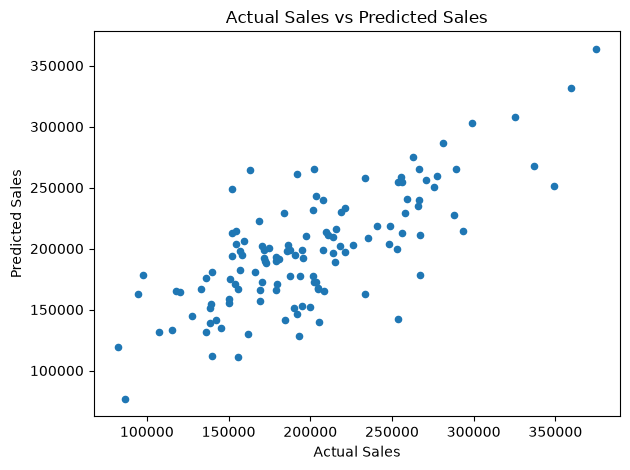

In [20]:
# 실제값 vs 예측값
figure_path = (
    output_dir
    / "customer_sales_actual_vs_predicted.png"
)

prediction_df.plot.scatter(
    x="actual_sales",
    y="predicted_sales"
)

plt.title(
    "Actual Sales vs Predicted Sales"
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 잔차 분석

잔차는 실제값에서 예측값을 뺀 값이다.

residual = actual - prediction

잔차가 0이면 실제값과 예측값이 같다.

양수라면 모델이 실제 매출보다 낮게 예측한 것이고,
음수라면 실제 매출보다 높게 예측한 것이다.

좋은 모델에서는 잔차가 특정 방향의 뚜렷한 패턴 없이
0 주변에 퍼져 있는지 확인한다.

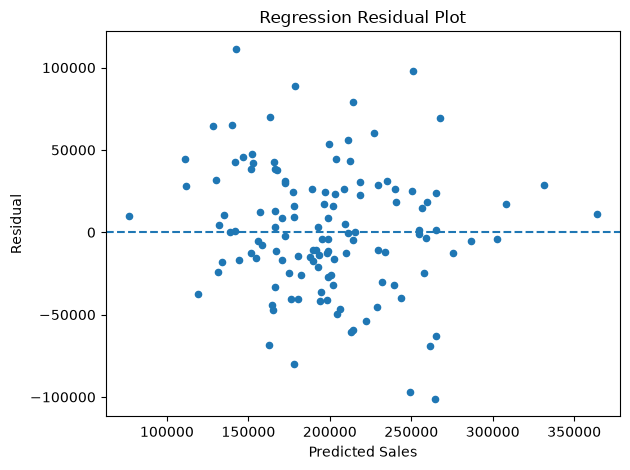

In [21]:
# 잔차 그래프
figure_path = (
    output_dir
    / "customer_sales_residual_plot.png"
)

prediction_df.plot.scatter(
    x="predicted_sales",
    y="residual"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Regression Residual Plot"
)

plt.xlabel(
    "Predicted Sales"
)

plt.ylabel(
    "Residual"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 핵심 결과

### 1. 데이터 분할

전체 고객: 500명

Train: 375명

Test: 125명

### 2. 기준선

Baseline MAE: 43902.539136

Train 데이터 평균값을 모든 Test 고객에게 예측하는
단순 모델의 평균 절대 오차다.


### 3. 선형회귀 성능

Model MAE: 29895.554335

Model RMSE: 38314.378900

Model R²: 0.543858


### 4. 기준선 비교

Baseline MAE: 43902.539136
Model MAE: 29895.554335

베이스라인보다 모델의 평균오차가 더 적다

### 5. 회귀계수

모든 변수가 양의 상관관계를 가지고 있다.

계수는 예측 모델의 관계를 나타내며,
인과효과를 의미하지 않는다.


### 6. 잔차

실제값과 예측값 사이에는 일정한 오차가 존재한다.

잔차 그래프를 확인하여
특정한 패턴이나 큰 오차가 존재하는지 확인했다.


### 7. 분석 한계

현재 데이터는 선형회귀 학습을 위해 생성한 가상 데이터다.

실제 고객 데이터에 동일한 관계가 존재한다고 볼 수 없으며,
회귀계수를 인과관계로 해석해서는 안 된다.

실전 모델에서는 실제 업무 데이터와 미래 Target 정의,
데이터 누수, 시간 기준 분할과 추가 검증이 필요하다.